# 06 — Fine tuning



`05` decidió la variante de dataset por familia (`arboles` para Random Forest y
XGBoost) con hiperparámetros por defecto, y con esos defaults los árboles ya
superan claramente a la vía lineal (`resultados_baseline.csv` tiene la
comparación exacta, cargada en §1). 

Este notebook ajusta los hiperparámetros para las dos familias de árboles; la familia lineal no se ajusta aquí.

Se hace tanto para las versiones desplegables (las que se pueden poner en producción) como para las versiones íntegras (las que nos indican el potencial del modelo si se tuviese acceso a más `features`de la API)-

`arboles_desplegable` es la variante que se puede alimentar desde la API
de idealista: sin variables de catastro ni `ISINTOPFLOOR`.

In [1]:
import os, sys, warnings
from pathlib import Path
from time import perf_counter

RAIZ = Path.cwd()
while not (RAIZ / "src").exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
os.chdir(RAIZ); sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint, uniform, loguniform
from xgboost import XGBRegressor

from src import rutas
from src.modelado import (
    ConApagado, cv_aleatorio, evaluar_cv, rango_entero, rango_log, rango_uniforme,
    refinar_con_apagado, registrar_experimento, vecinos_lista,
)

pd.set_option("display.max_columns", 60); pd.set_option("display.width", 170)
sns.set_theme(style="whitegrid")

SEMILLA = 42
PROCESADOS = rutas.PROCESADOS
RUTA_RESULTADOS = rutas.RUTA_RESULTADOS_AJUSTE
RUTA_RESULTADOS.parent.mkdir(parents=True, exist_ok=True)
RUTA_RESULTADOS.unlink(missing_ok=True)


## 1. Carga

Solo las variantes que ganaron en `05`.

In [2]:
y_train = pd.read_parquet(PROCESADOS / "y_train.parquet")["log_price"]

X_arboles = pd.read_parquet(PROCESADOS / "X_train_arboles.parquet")
X_arboles_desplegable = pd.read_parquet(PROCESADOS / "X_train_arboles_desplegable.parquet")

baseline = pd.read_csv(rutas.RUTA_RESULTADOS_BASELINE)
print(baseline[["nombre", "familia", "rmse_log_media", "rmse_log_std"]].to_string(index=False))


                      nombre              familia  rmse_log_media  rmse_log_std
                    incluido               lineal        0.227674      0.001433
                 desplegable               lineal        0.232106      0.001565
                stepwise_bic lineal (diagnóstico)        0.226070      0.001499
                     arboles        random_forest        0.188023      0.002285
              arboles_podado        random_forest        0.188874      0.002378
            arboles_completo        random_forest        0.189944      0.002490
         arboles_desplegable        random_forest        0.191721      0.002145
  arboles_podado_desplegable        random_forest        0.192632      0.002216
arboles_completo_desplegable        random_forest        0.193482      0.002109
                     arboles              xgboost        0.194441      0.002423
            arboles_completo              xgboost        0.195158      0.002417
         arboles_desplegable            

## 2. Diagnóstico: problemas sesgo-varianza en los parámetros convencionales

Antes de definir el espacio de búsqueda, conviene saber si el problema en los modelos `default` es
**varianza** (el árbol memoriza train y no generaliza -- pide más
regularización) o **sesgo** (el modelo es demasiado simple -- pide más
capacidad). Son rangos de hiperparámetros opuestos, así que no tiene sentido
lanzar una búsqueda amplia sin decidir primero cuál es.

### 2.1 Random Forest — forma real de los árboles

max_features por defecto: 1.0  (1.0 = cada split mira las 28 variables enteras -- sin submuestreo de columnas)
profundidad   media=39.5  mediana=39  rango=[35, 46]
hojas         media=37194  (1.6 filas/hoja de media, sobre 60,375 filas de train)

rmse_log train (dentro de muestra) = 0.0691
rmse_log CV (05, fuera de muestra)  = 0.1880
hueco train/CV = 0.1190  -> varianza, no sesgo: el árbol individual memoriza


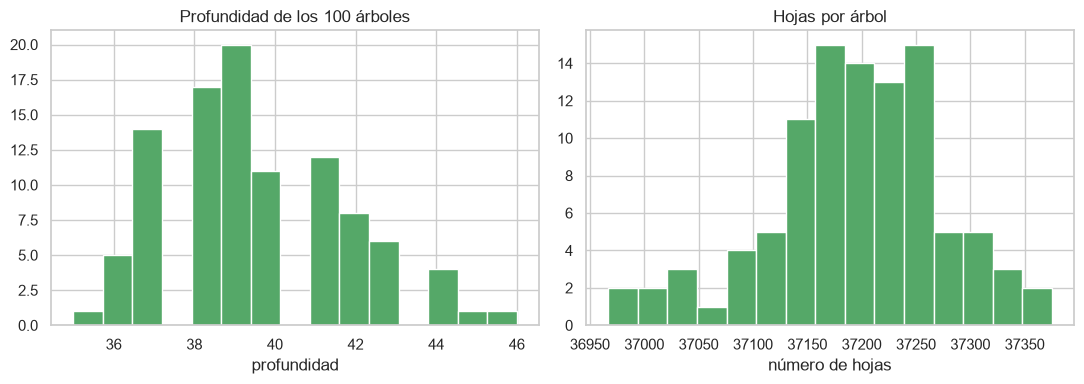

In [3]:
rf_defecto = RandomForestRegressor(random_state=SEMILLA, n_jobs=-1).fit(X_arboles, y_train)

profundidades = [e.get_depth() for e in rf_defecto.estimators_]
hojas = [e.get_n_leaves() for e in rf_defecto.estimators_]
rmse_train_rf = np.sqrt(mean_squared_error(y_train, rf_defecto.predict(X_arboles)))
rmse_cv_rf = baseline.loc[baseline.nombre.eq("arboles") & baseline.familia.eq("random_forest"), "rmse_log_media"].iloc[0]

print(f"max_features por defecto: {rf_defecto.max_features}  (1.0 = cada split mira las {X_arboles.shape[1]} variables enteras -- sin submuestreo de columnas)")
print(f"profundidad   media={np.mean(profundidades):.1f}  mediana={np.median(profundidades):.0f}  rango=[{min(profundidades)}, {max(profundidades)}]")
print(f"hojas         media={np.mean(hojas):.0f}  ({len(y_train)/np.mean(hojas):.1f} filas/hoja de media, sobre {len(y_train):,} filas de train)")
print(f"\nrmse_log train (dentro de muestra) = {rmse_train_rf:.4f}")
print(f"rmse_log CV (05, fuera de muestra)  = {rmse_cv_rf:.4f}")
print(f"hueco train/CV = {rmse_cv_rf - rmse_train_rf:.4f}  -> varianza, no sesgo: el árbol individual memoriza")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(profundidades, bins=15, color="#55A868")
axes[0].set_title("Profundidad de los 100 árboles")
axes[0].set_xlabel("profundidad")
axes[1].hist(hojas, bins=15, color="#55A868")
axes[1].set_title("Hojas por árbol")
axes[1].set_xlabel("n\u00famero de hojas")
plt.tight_layout()
plt.show()

**Lectura.** Con ~1,6 filas por hoja de media, cada árbol individual está
memorizando train, no aprendiendo estructura -- exactamente lo que predice
`min_samples_leaf=1` (el valor por defecto de `sklearn`) a esta profundidad. Y
con `max_features=1.0` (también el valor por defecto -- no `"sqrt"`, que era el
default en versiones antiguas de `sklearn`) los 100 árboles ven las mismas
variables en cada split, así que están mucho más correlacionados entre sí de
lo que el diseño de "random" forest asume: el promediado del *bagging* pierde
buena parte de su efecto reductor de varianza cuando los árboles que promedia
no son tan distintos entre sí.

Esto apunta a dos variables de regularización, no una: subir `min_samples_leaf`
(que cada árbol deje de memorizar) y bajar `max_features` (que los árboles se
decorrelen entre sí). El espacio de búsqueda de §3 las incluye a ambas.

### 2.2 XGBoost — curva de aprendizaje

Ejercicio similar para XGBoost, donde se comprueba como funciona el rendimiento del modelo en *train* y validación según van incrementando las iteraciones.

learning_rate por defecto = 0.3, max_depth = 6, n_estimators usados en 05 = 100
rmse_log train (dentro de muestra, 100 rondas) = 0.1669
rmse_log CV (05, fuera de muestra)              = 0.1944
hueco train/CV = 0.0275  -> menor que en RF, pero también varianza


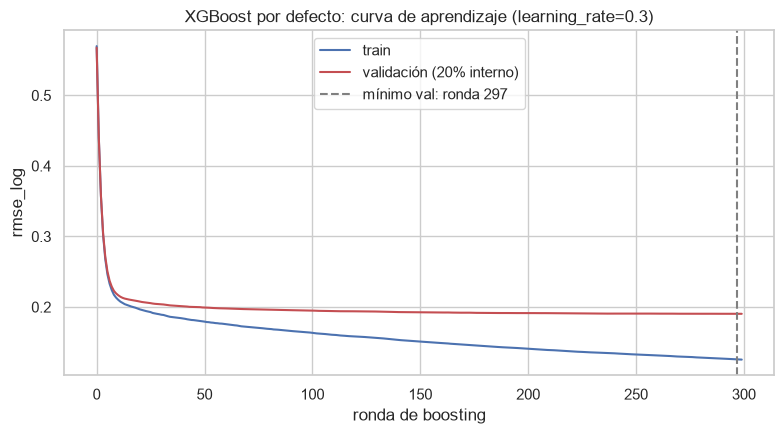


la validación interna toca mínimo en la ronda 297 de 300 -- rondas después de esa solo sobreajustan


In [4]:
X_tr, X_val, y_tr, y_val = train_test_split(X_arboles, y_train, test_size=0.2, random_state=SEMILLA)

xgb_defecto = XGBRegressor(
    random_state=SEMILLA, n_jobs=-1, n_estimators=300, eval_metric="rmse",
).fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)], verbose=False)

historial = xgb_defecto.evals_result()
clave_train, clave_val = "validation_0", "validation_1"

rmse_train_xgb = np.sqrt(mean_squared_error(y_train, XGBRegressor(random_state=SEMILLA, n_jobs=-1).fit(X_arboles, y_train).predict(X_arboles)))
rmse_cv_xgb = baseline.loc[baseline.nombre.eq("arboles") & baseline.familia.eq("xgboost"), "rmse_log_media"].iloc[0]

print(f"learning_rate por defecto = 0.3, max_depth = 6, n_estimators usados en 05 = 100")
print(f"rmse_log train (dentro de muestra, 100 rondas) = {rmse_train_xgb:.4f}")
print(f"rmse_log CV (05, fuera de muestra)              = {rmse_cv_xgb:.4f}")
print(f"hueco train/CV = {rmse_cv_xgb - rmse_train_xgb:.4f}  -> menor que en RF, pero también varianza")

ronda_minima = int(np.argmin(historial[clave_val]["rmse"]))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(historial[clave_train]["rmse"], label="train", color="#4C72B0")
ax.plot(historial[clave_val]["rmse"], label="validación (20% interno)", color="#C44E52")
ax.axvline(ronda_minima, linestyle="--", color="gray", label=f"mínimo val: ronda {ronda_minima}")
ax.set_xlabel("ronda de boosting"); ax.set_ylabel("rmse_log")
ax.set_title("XGBoost por defecto: curva de aprendizaje (learning_rate=0.3)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nla validación interna toca mínimo en la ronda {ronda_minima} de 300 -- rondas después de esa solo sobreajustan")

**Lectura.** El resultado es distinto de lo esperado: la validación interna
**no** toca mínimo antes de la ronda 300 -- lo toca en la ronda 296, prácticamente
al final de la ventana probada, y la curva de validación seguía bajando en
ese punto. Es decir: en `05` el modelo estaba **infraentrenado**, no
sobreajustado -- 100 rondas (las que usó `05` por defecto) se quedaron cortas
mucho antes de que `learning_rate=0.3` empezara a causar problemas.

Eso cambia la prioridad del espacio de búsqueda: la primera variable no es
bajar `learning_rate`, es subir `n_estimators` bastante por encima de 300 y
dejar que **early stopping** encuentre el punto real donde la validación deja
de mejorar, en vez de fijarlo a mano.

### 2.3 Importancia de variables

No decide nada por sí sola (04 ya lo hizo con ΔR² para la vía lineal), pero
sirve de contraste: ¿qué variables usan realmente los árboles con estos
datos, sin ajustar?

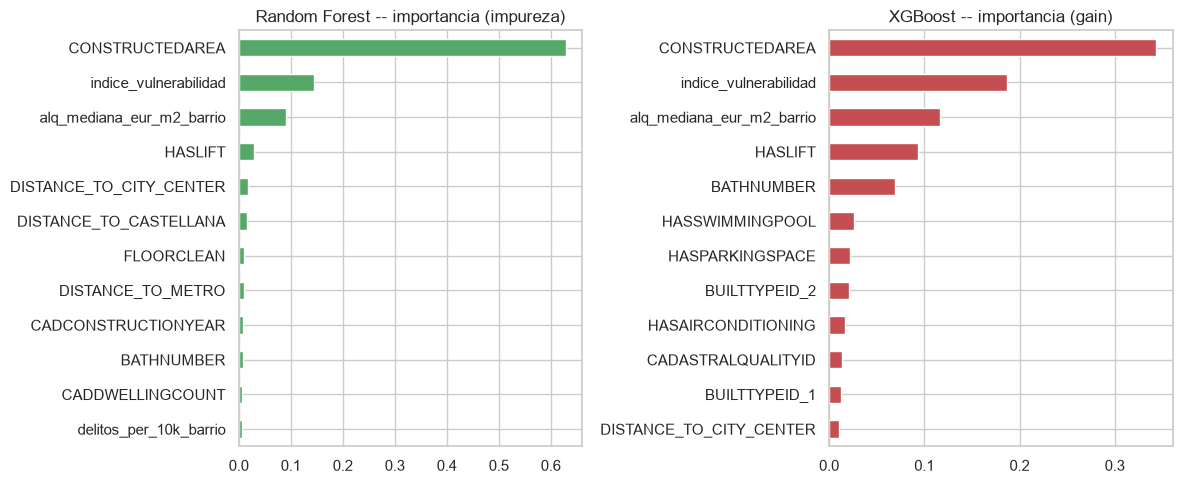

Top 5 RF:  ['CONSTRUCTEDAREA', 'indice_vulnerabilidad', 'alq_mediana_eur_m2_barrio', 'HASLIFT', 'DISTANCE_TO_CITY_CENTER']
Top 5 XGB: ['CONSTRUCTEDAREA', 'indice_vulnerabilidad', 'alq_mediana_eur_m2_barrio', 'HASLIFT', 'BATHNUMBER']


In [ ]:
imp_rf = pd.Series(rf_defecto.feature_importances_, index=X_arboles.columns).sort_values(ascending=False)
xgb_completo = XGBRegressor(random_state=SEMILLA, n_jobs=-1).fit(X_arboles, y_train)
imp_xgb = pd.Series(xgb_completo.feature_importances_, index=X_arboles.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
imp_rf.head(12)[::-1].plot.barh(ax=axes[0], color="#55A868")
axes[0].set_title("Random Forest -- importancia (impureza)")
imp_xgb.head(12)[::-1].plot.barh(ax=axes[1], color="#C44E52")
axes[1].set_title("XGBoost -- importancia (gain)")
plt.tight_layout()
plt.show()

Aunque las variables más importantes son constantes entre ambos modelos, vemos que RF da m

## 3. Espacio de búsqueda: qué tunear, a partir por §2


| familia | qué variable | por qué (evidencia de §2) |
|---|---|---|
| Random Forest | `min_samples_leaf` alto, `max_features` < 1.0, `max_depth` acotado, `max_samples` < 1.0, `min_impurity_decrease` > 0 | hojas de ~1,6 filas y `max_features=1.0` por defecto -- varianza y correlación entre árboles, no falta de capacidad |
| XGBoost | `n_estimators` alto + `early_stopping_rounds`, `learning_rate` bajo, `subsample`/`colsample_bytree` < 1, `reg_alpha`/`reg_lambda`, `gamma` | la validación interna aún bajaba en la ronda 300 -- infraentrenado, no sobreajustado; una vez con rondas suficientes, las mismas variables de decorrelación que en RF vuelven a ser razonables. Búsqueda en dos etapas (§5): una exploratoria amplia y una segunda, más fina, centrada en la región ganadora de la primera |

**Motor de búsqueda:** `RandomizedSearchCV` de `sklearn` sobre `KFold(5)`
Con `n≈60.000` filas y este número de hiperparámetros el coste de una búsqueda
aleatoria (en vez de un `grid search` estricto) más simple es bajo, y mantiene el pipeline explicable con las
herramientas que ya usa el resto del repositorio.

**Cada variable puede quedar anulada/nula.** §2 dice qué variables *podrían* ayudar,
no que todas ayuden. Por eso cada hiperparámetro de regularización incluye en
su espacio el valor que lo desactiva (`max_depth=None`, `max_samples=None`,
`max_features=1.0`, `min_samples_leaf=1`, `min_impurity_decrease=0`, `gamma=0`,
`subsample=1.0`, …). Para listas y enteros basta con incluir ese valor; para
las distribuciones continuas (`loguniform`, `uniform`), que nunca devuelven
exactamente 0 o 1, se usa `ConApagado` (`src/modelado.py`): con una
probabilidad fija devuelve el valor "nulo" y, si no, muestrea del rango. Sin
eso, todas las configuraciones de la búsqueda usarían la variable a la vez, y
la búsqueda no podría descubrir que lo mejor era no usarla.

**Escala de `min_impurity_decrease`.** `sklearn` no compara el umbral con la
reducción de impureza del nodo, sino con esa reducción **ponderada por la
fracción de filas del nodo*. En un nodo de 50 filas sobre ~48.000,
un umbral de `1e-5` exige que la varianza local de `log_price` baje ~0,01 --
mucho para un nodo pequeño, que ya es casi homogéneo. Un árbol único sobre
`arboles` pasa de ~58.700 hojas con umbral 0 a ~1.150 con `1e-5` y ~360 con
`3e-5`. Por eso el rango explorado es `loguniform(1e-8, 1e-5)`, más la opción
de apagarlo (0).


**Simplificación declarada para XGBoost:** `early_stopping_rounds` necesita un
`eval_set` de validación fijo, pero `RandomizedSearchCV` no puede pasarle un
`eval_set` distinto por fold sin un bucle manual. Se resuelve en dos fases:
(1) la búsqueda aleatoria fija `n_estimators` a un valor generoso (600 --
por encima de la ronda en la que la validación interna de §2.2 tocó
mínimo) para encontrar la combinación de las demás variables; (2) una vez
fijada esa combinación, un reajuste final con *early stopping* de verdad (uno
por fold) decide cuántas rondas usar en la práctica.

## 4. Random Forest — `RandomizedSearchCV` - Primera búsqueda (general)

In [6]:
espacio_rf = {
    "n_estimators": randint(200, 600),
    "max_features": ["sqrt", 0.3, 0.5, 0.7, 1.0],              # 1.0 = sin submuestreo de columnas
    "min_samples_leaf": ConApagado(randint(2, 40), valor_apagado=1),
    "min_samples_split": ConApagado(randint(3, 40), valor_apagado=2),
    "max_depth": [None, 8, 12, 16, 20, 24],                    # None = sin límite
    "max_samples": [None, 0.5, 0.7, 0.9],                      # None = bootstrap completo
    "min_impurity_decrease": ConApagado(loguniform(1e-8, 1e-5), valor_apagado=0.0, p_apagado=0.5),
}

busqueda_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=SEMILLA, n_jobs=1),
    espacio_rf, n_iter=40, cv=cv_aleatorio(5),
    scoring="neg_root_mean_squared_error", random_state=SEMILLA, n_jobs=-1,
)

t0 = perf_counter()
busqueda_rf.fit(X_arboles, y_train)
tiempo_rf = perf_counter() - t0

print(f"tiempo total: {tiempo_rf:.0f}s")
print(f"mejor rmse_log (CV): {-busqueda_rf.best_score_:.4f}")
print(f"mejores hiperparámetros: {busqueda_rf.best_params_}")


tiempo total: 1054s
mejor rmse_log (CV): 0.1833
mejores hiperparámetros: {'max_depth': None, 'max_features': 0.5, 'max_samples': None, 'min_impurity_decrease': np.float64(1.7104525858990505e-07), 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 325}


In [7]:
fila_rf = evaluar_cv(
    RandomForestRegressor(random_state=SEMILLA, n_jobs=-1, **busqueda_rf.best_params_),
    X_arboles, y_train, nombre="arboles_ajustado", familia="random_forest",
)
registrar_experimento(fila_rf, ruta=RUTA_RESULTADOS)

print(f"RF ajustado     : rmse_log = {fila_rf['rmse_log_media']:.4f} \u00b1 {fila_rf['rmse_log_std']:.4f}")
rmse_cv_rf_defecto = baseline.loc[baseline.nombre.eq("arboles") & baseline.familia.eq("random_forest"), "rmse_log_media"].iloc[0]
print(f"RF 05 (defecto) : rmse_log = {rmse_cv_rf_defecto:.4f}")
print(f"mejora: {rmse_cv_rf_defecto - fila_rf['rmse_log_media']:.4f}")


RF ajustado     : rmse_log = 0.1833 ± 0.0021
RF 05 (defecto) : rmse_log = 0.1880
mejora: 0.0048


### 4.1 Refinamiento: segunda búsqueda centrada en el ganador de la búsqueda general.

Mismo esquema que XGBoost usa en §5.1→§5.2: no una zona fija ("cerca del
*default*"), sino un espacio estrecho construido alrededor de
`busqueda_rf.best_params_`, el punto óptimo de la búsqueda anterior. Para los enteros y las variables con
`ConApagado` se usan `rango_entero`/`refinar_con_apagado`, igual que en §5.2.

Si la sección apagó una variable (`min_impurity_decrease=0`,
`min_samples_leaf=1`, …), la deja apagada, sin volver a plantear si
encenderla. Para `max_features`, `max_depth` y `max_samples` -- listas que
mezclan `None`/`"sqrt"` con valores discretos, sin un rango numérico que
estrechar -- `vecinos_lista` toma el valor ganador más sus vecinos inmediatos.

In [8]:
p_rf = busqueda_rf.best_params_

espacio_rf_ligero = {
    "n_estimators": rango_entero(p_rf["n_estimators"], 100, lo=100, hi=800),
    "max_features": vecinos_lista(espacio_rf["max_features"], p_rf["max_features"]),
    "min_samples_leaf": refinar_con_apagado(
        espacio_rf["min_samples_leaf"], p_rf["min_samples_leaf"],
        lambda c: rango_entero(c, 5, lo=1, hi=40),
    ),
    "min_samples_split": refinar_con_apagado(
        espacio_rf["min_samples_split"], p_rf["min_samples_split"],
        lambda c: rango_entero(c, 5, lo=2, hi=40),
    ),
    "max_depth": vecinos_lista(espacio_rf["max_depth"], p_rf["max_depth"]),
    "max_samples": vecinos_lista(espacio_rf["max_samples"], p_rf["max_samples"]),
    "min_impurity_decrease": refinar_con_apagado(
        espacio_rf["min_impurity_decrease"], p_rf["min_impurity_decrease"],
        lambda c: rango_log(c, factor=5, lo=1e-9, hi=1e-4),
    ),
}

busqueda_rf_ligero = RandomizedSearchCV(
    RandomForestRegressor(random_state=SEMILLA, n_jobs=1),
    espacio_rf_ligero, n_iter=20, cv=cv_aleatorio(5),
    scoring="neg_root_mean_squared_error", random_state=SEMILLA, n_jobs=-1,
)

t0 = perf_counter()
busqueda_rf_ligero.fit(X_arboles, y_train)
tiempo_rf_ligero = perf_counter() - t0

fila_rf_ligero = evaluar_cv(
    RandomForestRegressor(random_state=SEMILLA, n_jobs=-1, **busqueda_rf_ligero.best_params_),
    X_arboles, y_train, nombre="arboles_ajustado_ligero", familia="random_forest",
)
registrar_experimento(fila_rf_ligero, ruta=RUTA_RESULTADOS)

print(f"tiempo total: {tiempo_rf_ligero:.0f}s")
print(f"mejores hiperparámetros §4 (centro):     {p_rf}")
print(f"mejores hiperparámetros §4.1 (refinado): {busqueda_rf_ligero.best_params_}")
print(f"\nRF refinado (§4.1) : rmse_log = {fila_rf_ligero['rmse_log_media']:.4f} ± {fila_rf_ligero['rmse_log_std']:.4f}")
print(f"RF amplio (§4)     : rmse_log = {fila_rf['rmse_log_media']:.4f} ± {fila_rf['rmse_log_std']:.4f}")
print(f"RF 05 (defecto)    : rmse_log = {rmse_cv_rf_defecto:.4f}")
print(f"mejora vs defecto  : {rmse_cv_rf_defecto - fila_rf_ligero['rmse_log_media']:.4f}")

tiempo total: 454s
mejores hiperparámetros §4 (centro):     {'max_depth': None, 'max_features': 0.5, 'max_samples': None, 'min_impurity_decrease': np.float64(1.7104525858990505e-07), 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 325}
mejores hiperparámetros §4.1 (refinado): {'max_depth': None, 'max_features': 0.3, 'max_samples': None, 'min_impurity_decrease': np.float64(2.3497934138973534e-07), 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 299}

RF refinado (§4.1) : rmse_log = 0.1832 ± 0.0021
RF amplio (§4)     : rmse_log = 0.1833 ± 0.0021
RF 05 (defecto)    : rmse_log = 0.1880
mejora vs defecto  : 0.0048


In [9]:
candidatos_rf = {
    "defecto": rmse_cv_rf_defecto,
    "amplio (§4)": fila_rf["rmse_log_media"],
    "refinado (§4.1)": fila_rf_ligero["rmse_log_media"],
}
mejor_rf_nombre = min(candidatos_rf, key=candidatos_rf.get)

print("Random Forest -- las tres variantes, ordenadas:")
for nombre, valor in sorted(candidatos_rf.items(), key=lambda kv: kv[1]):
    marca = "  <- mejor" if nombre == mejor_rf_nombre else ""
    print(f"  {nombre:15s} rmse_log = {valor:.4f}{marca}")

if mejor_rf_nombre == "defecto":
    print("\nNi la búsqueda amplia ni su refinamiento mejoran el default: para esta variante")
    print("de dataset, con KFold aleatorio, Random Forest ya está cerca de su óptimo sin")
    print("ajustar. No es evidencia sobre otras variantes ni sobre otro esquema de validación")
    print("-- solo sobre esta combinación exacta.")
elif mejor_rf_nombre == "refinado (§4.1)":
    print("\nEl refinamiento alrededor del ganador de §4 encuentra margen que esa búsqueda")
    print("amplia, con solo 30 iteraciones repartidas por todo el espacio, no llegó a explotar.")
else:
    print("\nLa búsqueda amplia de §4 gana: el refinamiento a su alrededor no encuentra nada mejor.")

Random Forest -- las tres variantes, ordenadas:
  refinado (§4.1) rmse_log = 0.1832  <- mejor
  amplio (§4)     rmse_log = 0.1833
  defecto         rmse_log = 0.1880

El refinamiento alrededor del ganador de §4 encuentra margen que esa búsqueda
amplia, con solo 30 iteraciones repartidas por todo el espacio, no llegó a explotar.


## 5. XGBoost — búsqueda en dos etapas + *early stopping* para `n_estimators`

Al igual que para RF, se hace una primera búsqueda amplia, que localiza la región más "prometedora" del espacio de hiperparámetros y una segunda, más fina y centrada en esa región.
Después, *early stopping* real decide `n_estimators` (§5.3), y §5.4 mide el coste
de las variables no disponibles en producción con esa misma estructura. El ajuste
propio de la variante desplegable está en §6.

### 5.1 Búsqueda exploratoria

Espacio amplio, `n_estimators=600` fijo (justificación en §3). Incluye
`gamma` -- coste mínimo de reducción de pérdida para hacer un split más,
la variable de regularización de XGBoost que más se parece a
`min_impurity_decrease` en RF.

Igual que en §4, cada variable de regularización puede quedar apagada
(`ConApagado`): `subsample=1.0`, `colsample_bytree=1.0`, `min_child_weight=1`,
`gamma=0`, `reg_alpha=0`, `reg_lambda=0`.

In [10]:
espacio_xgb1 = {
    "max_depth": randint(2, 10),
    "learning_rate": loguniform(0.01, 0.2),
    "subsample": ConApagado(uniform(0.5, 0.5), valor_apagado=1.0),
    "colsample_bytree": ConApagado(uniform(0.4, 0.6), valor_apagado=1.0),
    "min_child_weight": ConApagado(randint(2, 20), valor_apagado=1),
    "gamma": ConApagado(loguniform(1e-4, 1.0), valor_apagado=0.0),
    "reg_alpha": ConApagado(loguniform(1e-3, 10), valor_apagado=0.0),
    "reg_lambda": ConApagado(loguniform(1e-2, 10), valor_apagado=0.0),
}

busqueda_xgb1 = RandomizedSearchCV(
    XGBRegressor(random_state=SEMILLA, n_jobs=1, n_estimators=600),
    espacio_xgb1, n_iter=40, cv=cv_aleatorio(5),
    scoring="neg_root_mean_squared_error", random_state=SEMILLA, n_jobs=-1,
)

t0 = perf_counter()
busqueda_xgb1.fit(X_arboles, y_train)
tiempo_xgb1 = perf_counter() - t0

print(f"tiempo total: {tiempo_xgb1:.0f}s")
print(f"mejor rmse_log (CV, n_estimators=600 fijo): {-busqueda_xgb1.best_score_:.4f}")
print(f"mejores hiperparámetros: {busqueda_xgb1.best_params_}")

tiempo total: 145s
mejor rmse_log (CV, n_estimators=600 fijo): 0.1817
mejores hiperparámetros: {'colsample_bytree': np.float64(0.4381350101716142), 'gamma': np.float64(0.0019986340778528873), 'learning_rate': np.float64(0.08896916672592671), 'max_depth': 9, 'min_child_weight': 4, 'reg_alpha': np.float64(0.003008686821445846), 'reg_lambda': np.float64(1.9158219548093167), 'subsample': np.float64(0.8854835899772805)}


### 5.2 Refinamiento

Similar a §4.1

In [11]:
p1 = busqueda_xgb1.best_params_
espacio_xgb2 = {
    "max_depth": rango_entero(p1["max_depth"], 3, lo=2, hi=12),
    "learning_rate": rango_log(p1["learning_rate"], factor=3, lo=0.005, hi=0.3),
    "subsample": refinar_con_apagado(
        espacio_xgb1["subsample"], p1["subsample"],
        lambda c: rango_uniforme(c, 0.15, lo=0.3, hi=1.0),
    ),
    "colsample_bytree": refinar_con_apagado(
        espacio_xgb1["colsample_bytree"], p1["colsample_bytree"],
        lambda c: rango_uniforme(c, 0.15, lo=0.3, hi=1.0),
    ),
    "min_child_weight": refinar_con_apagado(
        espacio_xgb1["min_child_weight"], p1["min_child_weight"],
        lambda c: rango_entero(c, 5, lo=1, hi=30),
    ),
    "gamma": refinar_con_apagado(
        espacio_xgb1["gamma"], p1["gamma"],
        lambda c: rango_log(c, factor=5, lo=1e-5, hi=2.0),
    ),
    "reg_alpha": refinar_con_apagado(
        espacio_xgb1["reg_alpha"], p1["reg_alpha"],
        lambda c: rango_log(c, factor=5, lo=1e-4, hi=20.0),
    ),
    "reg_lambda": refinar_con_apagado(
        espacio_xgb1["reg_lambda"], p1["reg_lambda"],
        lambda c: rango_log(c, factor=5, lo=1e-3, hi=20.0),
    ),
}

busqueda_xgb2 = RandomizedSearchCV(
    XGBRegressor(random_state=SEMILLA, n_jobs=1, n_estimators=600),
    espacio_xgb2, n_iter=40, cv=cv_aleatorio(5),
    scoring="neg_root_mean_squared_error", random_state=SEMILLA, n_jobs=-1,
)

t0 = perf_counter()
busqueda_xgb2.fit(X_arboles, y_train)
tiempo_xgb2 = perf_counter() - t0

print(f"tiempo total: {tiempo_xgb2:.0f}s")
print(f"mejor rmse_log (CV, n_estimators=600 fijo): {-busqueda_xgb2.best_score_:.4f}")
print(f"  (§5.1 había encontrado: {-busqueda_xgb1.best_score_:.4f})")
print(f"mejores hiperparámetros: {busqueda_xgb2.best_params_}")

tiempo total: 230s
mejor rmse_log (CV, n_estimators=600 fijo): 0.1799
  (§5.1 había encontrado: 0.1817)
mejores hiperparámetros: {'colsample_bytree': 1.0, 'gamma': np.float64(0.0008455974281855146), 'learning_rate': np.float64(0.03618918309243442), 'max_depth': 11, 'min_child_weight': 1, 'reg_alpha': np.float64(0.004051044435568245), 'reg_lambda': 0.0, 'subsample': np.float64(0.7805900189973131)}


### 5.3 Cuántas rondas hacen falta, de verdad

§5.1-§5.2 buscaron todos los hiperparámetros —salvo `n_estimators`— con
`n_estimators=600` fijo. Ese 600 es un presupuesto de conveniencia para poder
correr la búsqueda aleatoria a un coste razonable, no una respuesta a cuántas
rondas necesita el modelo. Incluirlo como un eje más de `RandomizedSearchCV`
gastaría muestras de la búsqueda en un hiperparámetro que tiene un método
mucho más barato y más preciso para decidirse —*early stopping*— y que además
depende del resto de hiperparámetros ya fijados, no al revés. Por eso se
decide en un paso separado, después de fijar la combinación ganadora de §5.2,
y no dentro de la búsqueda.

**Mecánica.** Con esa combinación fija, para cada uno de los 5 folds de
`cv_aleatorio` se reentrena con un techo alto (`n_estimators=3000`) y
*early stopping* real: dentro de ese fold, una porción de entrenamiento se
aparta como validación interna, y el ajuste se detiene en cuanto el RMSE
sobre esa validación deja de mejorar durante 50 rondas seguidas
(`early_stopping_rounds=50`) —la ronda en la que de verdad convenía parar,
`best_iteration`, y no una cota fijada a mano. Esto da cinco valores —uno por
fold—, no uno: la respuesta a "¿cuántas rondas hacen falta?" también tiene
varianza entre particiones. Se toma la mediana de esos cinco valores como
`n_estimators` definitivo, y con ese número fijo se reevalúa el modelo con la
misma CV de 5 folds que se usa en todo el notebook, para obtener una medida
de rendimiento comparable con el resto de la tabla.

**Por qué importa el resultado.** La mediana observada (835 rondas) queda
muy por encima tanto del 600 usado durante la búsqueda como, sobre todo, de
las 100 rondas por defecto que usó `05`. Esto confirma el diagnóstico de §2:
el XGBoost de la línea base no estaba sobreajustado, estaba **infraentrenado**
—se quedaba corto de rondas antes de que el resto de hiperparámetros llegara
a importar—. Dejar que *early stopping* encuentre el punto real, en vez de
fijarlo a mano, es lo que explica la mejora de RMSE frente a `05`
(0.1944 → 0.1801).

In [12]:
mejores_params_xgb = dict(busqueda_xgb2.best_params_)

rondas_optimas = []
for tr_idx, val_idx in cv_aleatorio(5).split(X_arboles, y_train):
    m = XGBRegressor(
        random_state=SEMILLA, n_jobs=-1, n_estimators=3000,
        eval_metric="rmse", early_stopping_rounds=50, **mejores_params_xgb,
    )
    m.fit(
        X_arboles.iloc[tr_idx], y_train.iloc[tr_idx],
        eval_set=[(X_arboles.iloc[val_idx], y_train.iloc[val_idx])], verbose=False,
    )
    rondas_optimas.append(m.best_iteration)

n_estimators_final = int(np.median(rondas_optimas))
print(f"rondas óptimas por fold: {rondas_optimas}")
print(f"mediana -> n_estimators final: {n_estimators_final}")

fila_xgb = evaluar_cv(
    XGBRegressor(random_state=SEMILLA, n_jobs=-1, n_estimators=n_estimators_final, **mejores_params_xgb),
    X_arboles, y_train, nombre="arboles_ajustado", familia="xgboost",
    n_estimators_final=n_estimators_final,
)
registrar_experimento(fila_xgb, ruta=RUTA_RESULTADOS)

rmse_cv_xgb_defecto = baseline.loc[baseline.nombre.eq("arboles") & baseline.familia.eq("xgboost"), "rmse_log_media"].iloc[0]
print(f"\nXGB ajustado     : rmse_log = {fila_xgb['rmse_log_media']:.4f} ± {fila_xgb['rmse_log_std']:.4f}")
print(f"XGB 05 (defecto) : rmse_log = {rmse_cv_xgb_defecto:.4f}")
print(f"mejora: {rmse_cv_xgb_defecto - fila_xgb['rmse_log_media']:.4f}")


rondas óptimas por fold: [628, 606, 835, 877, 894]
mediana -> n_estimators final: 835

XGB ajustado     : rmse_log = 0.1801 ± 0.0023
XGB 05 (defecto) : rmse_log = 0.1944
mejora: 0.0143


 Este resultado (0.1801) es, dentro del ruido de muestreo, equivalente al 0.1799 que reportó §5.2 a n_estimators=600 — no se espera que lo supere: los cinco folds no coinciden en cuántas rondas necesitan (606–894), así que cualquier valor único que se les aplique a todos deja algunos ligeramente cortos y otros ligeramente largos. El objetivo de esta sección no es batir esa cifra, sino sustituir un 600 elegido solo por presupuesto de búsqueda por un número que sí responde a cuándo deja de mejorar la validación — el que de verdad se reutiliza en 07 al reajustar sobre todo train.

### 5.4 Coste de las variables no disponibles en producción, con la estructura fija

`05` midió el coste de quitar las variables que la API no ofrece (`arboles` vs
`arboles_desplegable`) con hiperparámetros por defecto. Aquí se reutiliza la
estructura ganadora de §5.2 sin relanzar la búsqueda: la pregunta es "¿cuánto cuesta
quitar esas variables con la misma estructura?", no "¿qué estructura es óptima sin
ellas?" (esa la responde §6). Solo el número de rondas se recalcula (menos columnas
cambia la curva de aprendizaje).

In [ ]:
rondas_optimas_desplegable = []
for tr_idx, val_idx in cv_aleatorio(5).split(X_arboles_desplegable, y_train):
    m = XGBRegressor(
        random_state=SEMILLA, n_jobs=-1, n_estimators=3000,
        eval_metric="rmse", early_stopping_rounds=50, **mejores_params_xgb,
    )
    m.fit(
        X_arboles_desplegable.iloc[tr_idx], y_train.iloc[tr_idx],
        eval_set=[(X_arboles_desplegable.iloc[val_idx], y_train.iloc[val_idx])], verbose=False,
    )
    rondas_optimas_desplegable.append(m.best_iteration)

n_estimators_final_desplegable = int(np.median(rondas_optimas_desplegable))

fila_xgb_desplegable = evaluar_cv(
    XGBRegressor(random_state=SEMILLA, n_jobs=-1, n_estimators=n_estimators_final_desplegable, **mejores_params_xgb),
    X_arboles_desplegable, y_train, nombre="arboles_desplegable_estructura_arboles", familia="xgboost",
    n_estimators_final=n_estimators_final_desplegable,
)
registrar_experimento(fila_xgb_desplegable, ruta=RUTA_RESULTADOS)

rmse_cv_xgb_desplegable_defecto = baseline.loc[
    baseline.nombre.eq("arboles_desplegable") & baseline.familia.eq("xgboost"), "rmse_log_media"
].iloc[0]

print(f"arboles_desplegable: {X_arboles_desplegable.shape[1]} variables")
print(f"rondas óptimas por fold: {rondas_optimas_desplegable}")
print(f"mediana -> n_estimators final: {n_estimators_final_desplegable}")
print(f"\nCoste de las variables no disponibles, con la misma estructura:")
print(f"  arboles_ajustado                       : {fila_xgb['rmse_log_media']:.4f}")
print(f"  arboles_desplegable_estructura_arboles : {fila_xgb_desplegable['rmse_log_media']:.4f}")
print(f"  coste = {fila_xgb_desplegable['rmse_log_media'] - fila_xgb['rmse_log_media']:.4f}"
      f"  (sin ajustar hiperparámetros, había medido {rmse_cv_xgb_desplegable_defecto - rmse_cv_xgb_defecto:.4f})")

arboles_desplegable: 21 variables
rondas óptimas por fold: [577, 740, 537, 489, 619]
mediana -> n_estimators final: 577

XGB desplegable, estructura de arboles : rmse_log = 0.1869 ± 0.0019
XGB desplegable 05 (defecto)            : rmse_log = 0.1990

Coste de las variables no disponibles, con la misma estructura:
  arboles_ajustado                       : 0.1801
  arboles_desplegable_estructura_arboles : 0.1869
  coste = 0.0068  (05, sin ajustar, había medido 0.0046)


## 6. Ajuste propio de la variante desplegable

`arboles_desplegable` es el modelo que se aplica a anuncios en vivo, así que recibe el
mismo esfuerzo que `arboles`, en vez de heredar su estructura:

Mismos espacios de búsqueda (con sus valores de apagado), misma validación y mismas
semillas.

### 6.0 Diagnóstico

Los espacios de §3 se eligieron mirando `arboles`. Antes de reutilizarlos, se comprueba
que el diagnóstico de §2 sigue valiendo con 21 variables: si los árboles de Random Forest
siguen memorizando (hojas de 1-2 filas) y si XGBoost por defecto sigue infraentrenado a
300 rondas, las mismas variables y el `n_estimators=600` fijo de la búsqueda tienen
sentido igual.

Random Forest por defecto
  profundidad media: desplegable 38.9 | arboles 39.5
  filas por hoja:    desplegable 1.6 | arboles 1.6

XGBoost por defecto (learning_rate=0.3), validación interna del 20%
  ronda con mínimo de validación: desplegable 268 de 300 | arboles 297 de 300


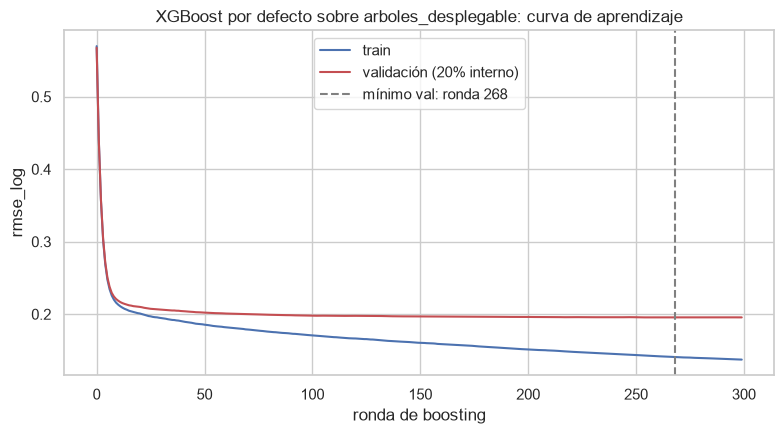

In [14]:
rf_defecto_desp = RandomForestRegressor(random_state=SEMILLA, n_jobs=-1).fit(X_arboles_desplegable, y_train)
profundidades_desp = [e.get_depth() for e in rf_defecto_desp.estimators_]
hojas_desp = [e.get_n_leaves() for e in rf_defecto_desp.estimators_]

print("Random Forest por defecto")
print(f"  profundidad media: desplegable {np.mean(profundidades_desp):.1f} | arboles {np.mean(profundidades):.1f}")
print(f"  filas por hoja:    desplegable {len(y_train) / np.mean(hojas_desp):.1f} | arboles {len(y_train) / np.mean(hojas):.1f}")

X_tr_d, X_val_d, y_tr_d, y_val_d = train_test_split(X_arboles_desplegable, y_train, test_size=0.2, random_state=SEMILLA)
xgb_curva_desp = XGBRegressor(
    random_state=SEMILLA, n_jobs=-1, n_estimators=300, eval_metric="rmse",
).fit(X_tr_d, y_tr_d, eval_set=[(X_tr_d, y_tr_d), (X_val_d, y_val_d)], verbose=False)
historial_desp = xgb_curva_desp.evals_result()
ronda_minima_desp = int(np.argmin(historial_desp["validation_1"]["rmse"]))

print("\nXGBoost por defecto (learning_rate=0.3), validación interna del 20%")
print(f"  ronda con mínimo de validación: desplegable {ronda_minima_desp} de 300 | arboles {ronda_minima} de 300")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(historial_desp["validation_0"]["rmse"], label="train", color="#4C72B0")
ax.plot(historial_desp["validation_1"]["rmse"], label="validación (20% interno)", color="#C44E52")
ax.axvline(ronda_minima_desp, linestyle="--", color="gray", label=f"mínimo val: ronda {ronda_minima_desp}")
ax.set_xlabel("ronda de boosting"); ax.set_ylabel("rmse_log")
ax.set_title("XGBoost por defecto sobre arboles_desplegable: curva de aprendizaje")
ax.legend()
plt.tight_layout()
plt.show()

### 6.1 Random Forest — búsqueda amplia

In [15]:
busqueda_rf_desp = RandomizedSearchCV(
    RandomForestRegressor(random_state=SEMILLA, n_jobs=1),
    espacio_rf, n_iter=40, cv=cv_aleatorio(5),
    scoring="neg_root_mean_squared_error", random_state=SEMILLA, n_jobs=-1,
)

t0 = perf_counter()
busqueda_rf_desp.fit(X_arboles_desplegable, y_train)
tiempo_rf_desp = perf_counter() - t0

fila_rf_desp = evaluar_cv(
    RandomForestRegressor(random_state=SEMILLA, n_jobs=-1, **busqueda_rf_desp.best_params_),
    X_arboles_desplegable, y_train, nombre="arboles_desplegable_ajustado", familia="random_forest",
)
registrar_experimento(fila_rf_desp, ruta=RUTA_RESULTADOS)

rmse_cv_rf_desp_defecto = baseline.loc[
    baseline.nombre.eq("arboles_desplegable") & baseline.familia.eq("random_forest"), "rmse_log_media"
].iloc[0]

print(f"tiempo total: {tiempo_rf_desp:.0f}s")
print(f"mejores hiperparámetros: {busqueda_rf_desp.best_params_}")
print(f"  (sobre arboles, §4:     {busqueda_rf.best_params_})")
print(f"\nRF desplegable ajustado : rmse_log = {fila_rf_desp['rmse_log_media']:.4f} ± {fila_rf_desp['rmse_log_std']:.4f}")
print(f"RF desplegable 05       : rmse_log = {rmse_cv_rf_desp_defecto:.4f}")
print(f"mejora: {rmse_cv_rf_desp_defecto - fila_rf_desp['rmse_log_media']:.4f}")

tiempo total: 812s
mejores hiperparámetros: {'max_depth': None, 'max_features': 0.5, 'max_samples': None, 'min_impurity_decrease': np.float64(1.7104525858990505e-07), 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 325}
  (sobre arboles, §4:     {'max_depth': None, 'max_features': 0.5, 'max_samples': None, 'min_impurity_decrease': np.float64(1.7104525858990505e-07), 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 325})

RF desplegable ajustado : rmse_log = 0.1868 ± 0.0021
RF desplegable 05       : rmse_log = 0.1917
mejora: 0.0050


### 6.1.1 Refinamiento: segunda búsqueda centrada en el ganador de §6.1

Mismas reglas que §4.1: espacio estrecho alrededor de `busqueda_rf_desp.best_params_`,
las variables apagadas en §6.1 se quedan apagadas y las listas se reducen al ganador y
sus vecinos. 20 iteraciones, igual que §4.1.

In [16]:
p_rf_desp = busqueda_rf_desp.best_params_

espacio_rf_ligero_desp = {
    "n_estimators": rango_entero(p_rf_desp["n_estimators"], 100, lo=100, hi=800),
    "max_features": vecinos_lista(espacio_rf["max_features"], p_rf_desp["max_features"]),
    "min_samples_leaf": refinar_con_apagado(
        espacio_rf["min_samples_leaf"], p_rf_desp["min_samples_leaf"],
        lambda c: rango_entero(c, 5, lo=1, hi=40),
    ),
    "min_samples_split": refinar_con_apagado(
        espacio_rf["min_samples_split"], p_rf_desp["min_samples_split"],
        lambda c: rango_entero(c, 5, lo=2, hi=40),
    ),
    "max_depth": vecinos_lista(espacio_rf["max_depth"], p_rf_desp["max_depth"]),
    "max_samples": vecinos_lista(espacio_rf["max_samples"], p_rf_desp["max_samples"]),
    "min_impurity_decrease": refinar_con_apagado(
        espacio_rf["min_impurity_decrease"], p_rf_desp["min_impurity_decrease"],
        lambda c: rango_log(c, factor=5, lo=1e-9, hi=1e-4),
    ),
}

busqueda_rf_ligero_desp = RandomizedSearchCV(
    RandomForestRegressor(random_state=SEMILLA, n_jobs=1),
    espacio_rf_ligero_desp, n_iter=20, cv=cv_aleatorio(5),
    scoring="neg_root_mean_squared_error", random_state=SEMILLA, n_jobs=-1,
)

t0 = perf_counter()
busqueda_rf_ligero_desp.fit(X_arboles_desplegable, y_train)
tiempo_rf_ligero_desp = perf_counter() - t0

fila_rf_ligero_desp = evaluar_cv(
    RandomForestRegressor(random_state=SEMILLA, n_jobs=-1, **busqueda_rf_ligero_desp.best_params_),
    X_arboles_desplegable, y_train, nombre="arboles_desplegable_ajustado_ligero", familia="random_forest",
)
registrar_experimento(fila_rf_ligero_desp, ruta=RUTA_RESULTADOS)

print(f"tiempo total: {tiempo_rf_ligero_desp:.0f}s")
print(f"mejores hiperparámetros §6.1 (centro):       {p_rf_desp}")
print(f"mejores hiperparámetros §6.1.1 (refinado):   {busqueda_rf_ligero_desp.best_params_}")

candidatos_rf_desp = {
    "defecto": rmse_cv_rf_desp_defecto,
    "amplio (§6.1)": fila_rf_desp["rmse_log_media"],
    "refinado (§6.1.1)": fila_rf_ligero_desp["rmse_log_media"],
}
mejor_rf_desp = min(candidatos_rf_desp, key=candidatos_rf_desp.get)
print("\nRandom Forest desplegable -- las tres variantes, ordenadas:")
for nombre, valor in sorted(candidatos_rf_desp.items(), key=lambda kv: kv[1]):
    marca = "  <- mejor" if nombre == mejor_rf_desp else ""
    print(f"  {nombre:18s} rmse_log = {valor:.4f}{marca}")

tiempo total: 337s
mejores hiperparámetros §6.1 (centro):       {'max_depth': None, 'max_features': 0.5, 'max_samples': None, 'min_impurity_decrease': np.float64(1.7104525858990505e-07), 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 325}
mejores hiperparámetros §6.1.1 (refinado):   {'max_depth': None, 'max_features': 0.3, 'max_samples': None, 'min_impurity_decrease': np.float64(2.3497934138973534e-07), 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 299}

Random Forest desplegable -- las tres variantes, ordenadas:
  refinado (§6.1.1)  rmse_log = 0.1868  <- mejor
  amplio (§6.1)      rmse_log = 0.1868
  defecto            rmse_log = 0.1917


### 6.2 XGBoost — dos etapas + *early stopping*

Mismo esquema que §5.1-§5.3. `espacio_refinado_xgb` construye el espacio de la segunda
etapa con las mismas reglas que §5.2, alrededor del ganador de la primera sobre esta
variante.

In [17]:
def espacio_refinado_xgb(p):
    return {
        "max_depth": rango_entero(p["max_depth"], 3, lo=2, hi=12),
        "learning_rate": rango_log(p["learning_rate"], factor=3, lo=0.005, hi=0.3),
        "subsample": refinar_con_apagado(
            espacio_xgb1["subsample"], p["subsample"],
            lambda c: rango_uniforme(c, 0.15, lo=0.3, hi=1.0),
        ),
        "colsample_bytree": refinar_con_apagado(
            espacio_xgb1["colsample_bytree"], p["colsample_bytree"],
            lambda c: rango_uniforme(c, 0.15, lo=0.3, hi=1.0),
        ),
        "min_child_weight": refinar_con_apagado(
            espacio_xgb1["min_child_weight"], p["min_child_weight"],
            lambda c: rango_entero(c, 5, lo=1, hi=30),
        ),
        "gamma": refinar_con_apagado(
            espacio_xgb1["gamma"], p["gamma"],
            lambda c: rango_log(c, factor=5, lo=1e-5, hi=2.0),
        ),
        "reg_alpha": refinar_con_apagado(
            espacio_xgb1["reg_alpha"], p["reg_alpha"],
            lambda c: rango_log(c, factor=5, lo=1e-4, hi=20.0),
        ),
        "reg_lambda": refinar_con_apagado(
            espacio_xgb1["reg_lambda"], p["reg_lambda"],
            lambda c: rango_log(c, factor=5, lo=1e-3, hi=20.0),
        ),
    }


busqueda_xgb1_desp = RandomizedSearchCV(
    XGBRegressor(random_state=SEMILLA, n_jobs=1, n_estimators=600),
    espacio_xgb1, n_iter=40, cv=cv_aleatorio(5),
    scoring="neg_root_mean_squared_error", random_state=SEMILLA, n_jobs=-1,
)
t0 = perf_counter()
busqueda_xgb1_desp.fit(X_arboles_desplegable, y_train)
tiempo_xgb1_desp = perf_counter() - t0

busqueda_xgb2_desp = RandomizedSearchCV(
    XGBRegressor(random_state=SEMILLA, n_jobs=1, n_estimators=600),
    espacio_refinado_xgb(busqueda_xgb1_desp.best_params_), n_iter=40, cv=cv_aleatorio(5),
    scoring="neg_root_mean_squared_error", random_state=SEMILLA, n_jobs=-1,
)
t0 = perf_counter()
busqueda_xgb2_desp.fit(X_arboles_desplegable, y_train)
tiempo_xgb2_desp = perf_counter() - t0

print(f"etapa exploratoria: {tiempo_xgb1_desp:.0f}s | mejor rmse_log (600 rondas fijas) {-busqueda_xgb1_desp.best_score_:.4f}")
print(f"etapa refinada:     {tiempo_xgb2_desp:.0f}s | mejor rmse_log (600 rondas fijas) {-busqueda_xgb2_desp.best_score_:.4f}")
print(f"\nhiperparámetros propios de desplegable: {busqueda_xgb2_desp.best_params_}")
print(f"hiperparámetros de arboles (§5.2):      {mejores_params_xgb}")

etapa exploratoria: 118s | mejor rmse_log (600 rondas fijas) 0.1876
etapa refinada:     207s | mejor rmse_log (600 rondas fijas) 0.1860

hiperparámetros propios de desplegable: {'colsample_bytree': np.float64(0.528081635815584), 'gamma': np.float64(0.0005361223891082169), 'learning_rate': np.float64(0.08788507761298064), 'max_depth': 12, 'min_child_weight': 5, 'reg_alpha': np.float64(0.0034879036214009018), 'reg_lambda': np.float64(8.659692055247017), 'subsample': np.float64(0.9568742693092576)}
hiperparámetros de arboles (§5.2):      {'colsample_bytree': 1.0, 'gamma': np.float64(0.0008455974281855146), 'learning_rate': np.float64(0.03618918309243442), 'max_depth': 11, 'min_child_weight': 1, 'reg_alpha': np.float64(0.004051044435568245), 'reg_lambda': 0.0, 'subsample': np.float64(0.7805900189973131)}


In [18]:
mejores_params_xgb_desp = dict(busqueda_xgb2_desp.best_params_)

rondas_optimas_desp = []
for tr_idx, val_idx in cv_aleatorio(5).split(X_arboles_desplegable, y_train):
    m = XGBRegressor(
        random_state=SEMILLA, n_jobs=-1, n_estimators=3000,
        eval_metric="rmse", early_stopping_rounds=50, **mejores_params_xgb_desp,
    )
    m.fit(
        X_arboles_desplegable.iloc[tr_idx], y_train.iloc[tr_idx],
        eval_set=[(X_arboles_desplegable.iloc[val_idx], y_train.iloc[val_idx])], verbose=False,
    )
    rondas_optimas_desp.append(m.best_iteration)

n_estimators_final_desp = int(np.median(rondas_optimas_desp))

fila_xgb_desp = evaluar_cv(
    XGBRegressor(random_state=SEMILLA, n_jobs=-1, n_estimators=n_estimators_final_desp, **mejores_params_xgb_desp),
    X_arboles_desplegable, y_train, nombre="arboles_desplegable_ajustado", familia="xgboost",
    n_estimators_final=n_estimators_final_desp,
)
registrar_experimento(fila_xgb_desp, ruta=RUTA_RESULTADOS)

print(f"rondas óptimas por fold: {rondas_optimas_desp} -> n_estimators final: {n_estimators_final_desp}")
print(f"\nXGB desplegable, ajuste propio (§6.2)          : rmse_log = {fila_xgb_desp['rmse_log_media']:.4f} ± {fila_xgb_desp['rmse_log_std']:.4f}")
print(f"XGB desplegable, estructura de arboles (§5.4)  : rmse_log = {fila_xgb_desplegable['rmse_log_media']:.4f} ± {fila_xgb_desplegable['rmse_log_std']:.4f}")
print(f"RF desplegable, ajuste propio (§6.1)           : rmse_log = {fila_rf_desp['rmse_log_media']:.4f} ± {fila_rf_desp['rmse_log_std']:.4f}")
print(f"XGB arboles, ganador con catastro (§5.3)       : rmse_log = {fila_xgb['rmse_log_media']:.4f} ± {fila_xgb['rmse_log_std']:.4f}")
print(f"\nmejora del ajuste propio frente a la estructura heredada: "
      f"{fila_xgb_desplegable['rmse_log_media'] - fila_xgb_desp['rmse_log_media']:+.4f}")

rondas óptimas por fold: [398, 412, 411, 410, 388] -> n_estimators final: 410

XGB desplegable, ajuste propio (§6.2)          : rmse_log = 0.1858 ± 0.0016
XGB desplegable, estructura de arboles (§5.4)  : rmse_log = 0.1869 ± 0.0019
RF desplegable, ajuste propio (§6.1)           : rmse_log = 0.1868 ± 0.0021
XGB arboles, ganador con catastro (§5.3)       : rmse_log = 0.1801 ± 0.0023

mejora del ajuste propio frente a la estructura heredada: +0.0012


## 7. Comparación global y contrato con `07_evaluacion_final.ipynb`

Todo lo evaluado en este notebook, línea base incluida como referencia. Las variantes
desplegables (§5.4, §6) aparecen en la tabla pero no compiten por el título de "ganador
global": esa pregunta es de disponibilidad en producción, no de mejor `rmse_log` puro
(misma postura que `05 §6`). Entre ellas se elige aparte el candidato de producción.

                                nombre       familia  rmse_log_media  rmse_log_std
                      arboles_ajustado       xgboost        0.180140      0.002301
               arboles_ajustado_ligero random_forest        0.183178      0.002091
                      arboles_ajustado random_forest        0.183257      0.002101
          arboles_desplegable_ajustado       xgboost        0.185772      0.001560
   arboles_desplegable_ajustado_ligero random_forest        0.186766      0.001777
          arboles_desplegable_ajustado random_forest        0.186768      0.002074
arboles_desplegable_estructura_arboles       xgboost        0.186939      0.001929
             arboles (05, por defecto) random_forest        0.188023      0.002285
 arboles_desplegable (05, por defecto) random_forest        0.191721      0.002145
             arboles (05, por defecto)       xgboost        0.194441      0.002423
 arboles_desplegable (05, por defecto)       xgboost        0.199030      0.002035


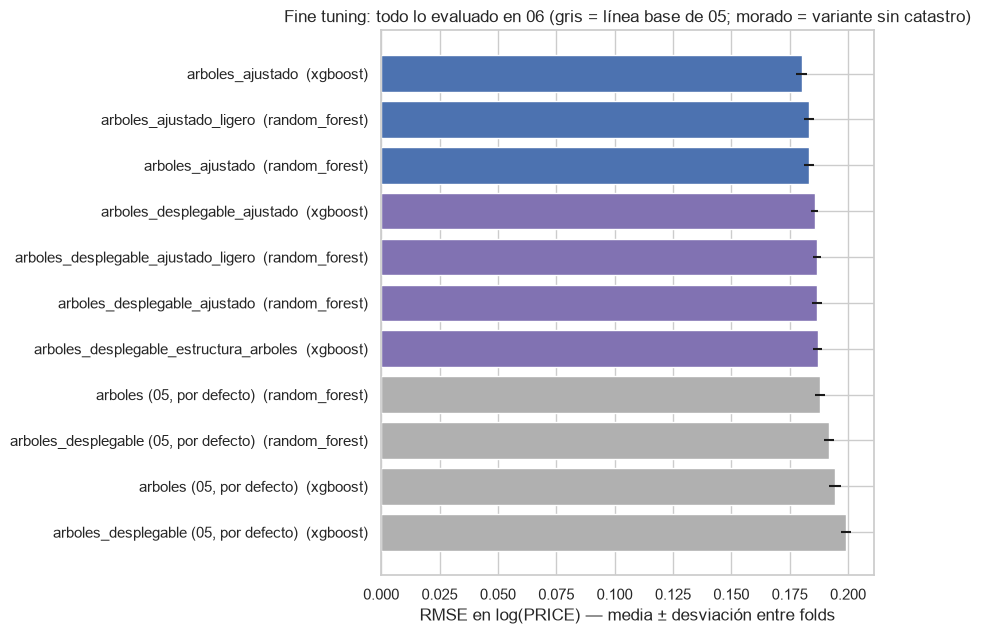

In [19]:
baseline_contraste = baseline[
    baseline["nombre"].isin(["arboles", "arboles_desplegable"])
    & baseline["familia"].isin(["random_forest", "xgboost"])
].copy()
baseline_contraste["nombre"] = baseline_contraste["nombre"] + " (05, por defecto)"

resultados_06 = pd.concat(
    [pd.read_csv(RUTA_RESULTADOS), baseline_contraste], ignore_index=True
).sort_values("rmse_log_media")
print(resultados_06[["nombre", "familia", "rmse_log_media", "rmse_log_std"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6.5))
etiquetas = resultados_06["nombre"] + "  (" + resultados_06["familia"] + ")"
colores = [
    "#B0B0B0" if "(05, por defecto)" in n else ("#8172B2" if "desplegable" in n else "#4C72B0")
    for n in resultados_06["nombre"]
]
ax.barh(etiquetas, resultados_06["rmse_log_media"], xerr=resultados_06["rmse_log_std"], color=colores)
ax.invert_yaxis()
ax.set_xlabel("RMSE en log(PRICE) — media ± desviación entre folds")
ax.set_title("Fine tuning: todo lo evaluado en 06 (gris = línea base de 05; morado = variante sin catastro)")
plt.tight_layout()
plt.show()


Pasan a `07` dos modelos:

- **ganador global**: menor `rmse_log` medio entre los modelos ajustados sobre variantes
  con todas las variables;
- **candidato de producción**: menor `rmse_log` medio entre los modelos ajustados sobre
  `arboles_desplegable`.

`07` los reajusta sobre todo train y los evalúa **una sola vez** sobre test. Sus
configuraciones (variante de dataset, familia, hiperparámetros y número de rondas) se
escriben en `data/results/modelos_seleccionados_06.json`, para que `07` no tenga
que copiarlas a mano.

In [20]:
import json

es_defecto = resultados_06["nombre"].str.contains(r"\(05, por defecto\)", na=False)
es_desplegable = resultados_06["nombre"].str.contains("desplegable", na=False)

ganador_global = resultados_06[~es_defecto & ~es_desplegable].sort_values("rmse_log_media").iloc[0]
candidatos_prod = resultados_06[~es_defecto & es_desplegable].sort_values("rmse_log_media")
fila_prod = candidatos_prod.iloc[0]

print(f">> Ganador global: {ganador_global['nombre']} ({ganador_global['familia']})")
print(f"   rmse_log CV = {ganador_global['rmse_log_media']:.4f} ± {ganador_global['rmse_log_std']:.4f}")
print(f"\n>> Candidato de producción: {fila_prod['nombre']} ({fila_prod['familia']})")
print(f"   rmse_log CV = {fila_prod['rmse_log_media']:.4f} ± {fila_prod['rmse_log_std']:.4f}"
      f"  (coste vs. ganador global: {fila_prod['rmse_log_media'] - ganador_global['rmse_log_media']:.4f})")
print("\nVariantes desplegables ajustadas:")
print(candidatos_prod[["nombre", "familia", "n_columnas", "rmse_log_media", "rmse_log_std", "n_estimators_final"]].to_string(index=False))

CONFIGURACIONES = {
    ("arboles_ajustado", "random_forest"): ("arboles", busqueda_rf.best_params_),
    ("arboles_ajustado_ligero", "random_forest"): ("arboles", busqueda_rf_ligero.best_params_),
    ("arboles_ajustado", "xgboost"): ("arboles", {**mejores_params_xgb, "n_estimators": n_estimators_final}),
    ("arboles_desplegable_estructura_arboles", "xgboost"):
        ("arboles_desplegable", {**mejores_params_xgb, "n_estimators": n_estimators_final_desplegable}),
    ("arboles_desplegable_ajustado", "random_forest"): ("arboles_desplegable", busqueda_rf_desp.best_params_),
    ("arboles_desplegable_ajustado_ligero", "random_forest"):
        ("arboles_desplegable", busqueda_rf_ligero_desp.best_params_),
    ("arboles_desplegable_ajustado", "xgboost"):
        ("arboles_desplegable", {**mejores_params_xgb_desp, "n_estimators": n_estimators_final_desp}),
}


def _a_json(params):
    return {k: (v.item() if hasattr(v, "item") else v) for k, v in params.items()}


seleccion = {}
for rol, fila in [("ganador_global", ganador_global), ("produccion", fila_prod)]:
    dataset, params = CONFIGURACIONES[(fila["nombre"], fila["familia"])]
    seleccion[rol] = {
        "nombre": fila["nombre"], "familia": fila["familia"], "dataset": dataset,
        "params": _a_json(params),
        "rmse_log_cv": float(fila["rmse_log_media"]), "rmse_log_cv_std": float(fila["rmse_log_std"]),
    }

ruta_seleccion = rutas.RUTA_SELECCION_MODELOS
ruta_seleccion.write_text(json.dumps(seleccion, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"\nConfiguraciones escritas en {ruta_seleccion}")

>> Ganador global: arboles_ajustado (xgboost)
   rmse_log CV = 0.1801 ± 0.0023

>> Candidato de producción: arboles_desplegable_ajustado (xgboost)
   rmse_log CV = 0.1858 ± 0.0016  (coste vs. ganador global: 0.0056)

Variantes desplegables ajustadas:
                                nombre       familia  n_columnas  rmse_log_media  rmse_log_std  n_estimators_final
          arboles_desplegable_ajustado       xgboost        21.0        0.185772      0.001560               410.0
   arboles_desplegable_ajustado_ligero random_forest        21.0        0.186766      0.001777                 NaN
          arboles_desplegable_ajustado random_forest        21.0        0.186768      0.002074                 NaN
arboles_desplegable_estructura_arboles       xgboost        21.0        0.186939      0.001929               577.0

Configuraciones escritas en C:\Users\tomas\Documents\Master\habitia-madrid\data\results\modelos_seleccionados_06.json
